In [1]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [2]:
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1
)

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



In [6]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

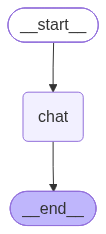

In [7]:
app

In [8]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [9]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='8bc7050b-ac66-46df-9043-028fbbb7d748')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='5d08fc586043092a814ecfaeacb11bcd')]}

In [10]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [11]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [12]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [13]:
print(final_result["messages"][-1].content)

**Gradient descent in a nutshell**

Imagine you’re standing on a hilly landscape at night, and you want to find the lowest point (the bottom of a valley). You can’t see the whole map, but you have a flashlight that tells you the slope of the ground right where you’re standing.

1. **Look at the slope** – The flashlight shows you which direction is “downhill” and how steep it is. In math, this slope is called the **gradient**.

2. **Take a step downhill** – You walk a little bit in the direction the slope points. How far you walk is decided by a knob called the **learning rate** (a small step size).  
   - If the step is too big, you might jump over the valley and end up on a higher hill.  
   - If the step is too tiny, you’ll crawl forever.

3. **Repeat** – At the new spot, you check the slope again, take another step, and keep doing this over and over.

4. **Stop when you’re flat** – Eventually the slope becomes (almost) zero – you’re at a flat spot, which is usually the bottom of the